# Notebook 3 — Análise Descritiva dos Dados (EDA)
**Projeto:** Predição de Evasão Escolar em Pernambuco  
**Disciplina:** Aprendizagem de Máquina | **Entrega:** 11/05/2026
---

## 1. Objetivos

1. Compreender a distribuição da variável-alvo e das principais features  
2. Verificar empiricamente as hipóteses levantadas no Notebook 1  
3. Identificar padrões de missing e decidir estratégia de imputação  
4. Analisar correlações entre infraestrutura, taxas de rendimento e evasão  
5. Produzir visualizações interpretáveis para apoiar a narrativa do relatório

## 2. Importações e Carregamento

In [9]:
from pathlib import Path
import os

# Garante que o diretório de trabalho é sempre a raiz do projeto
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
print(f'Diretório de trabalho: {PROJECT_ROOT}')

Diretório de trabalho: /Users/joaogui/Downloads/1VA_Aprendizado_Maquina


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

AZUL   = '#378ADD'
VERDE  = '#1D9E75'
CORAL  = '#D85A30'
CINZA  = '#888780'
AMARELO = '#BA7517'

# Carregar dataset municipal (gerado no Notebook 2 — Seção 13)
df = pd.read_csv('data/processed/dataset_integrado.csv')
df_ufs = df.copy()  # cada linha é um município × localização × dependência

print(f"Dataset municipal: {df_ufs.shape}")
print(f"Municípios únicos: {df_ufs['cod_municipio'].nunique()}")
print(f"UFs: {df_ufs['uf'].nunique()}")
print(f"Localizações: {df_ufs['localizacao'].unique().tolist()}")
print(f"Dependências: {df_ufs['dependencia_adm'].unique().tolist()}")
print(f"Variável-alvo — alto risco: {df_ufs['risco_evasao'].sum()} ({df_ufs['risco_evasao'].mean()*100:.1f}%)")

Dataset municipal: (50140, 84)
Municípios únicos: 5570
UFs: 27
Localizações: ['Total', 'Urbana', 'Rural']
Dependências: ['Total', 'Estadual', 'Municipal', 'Federal', 'Privada']
Variável-alvo — alto risco: 12425 (24.8%)


## 3. Dados Faltantes

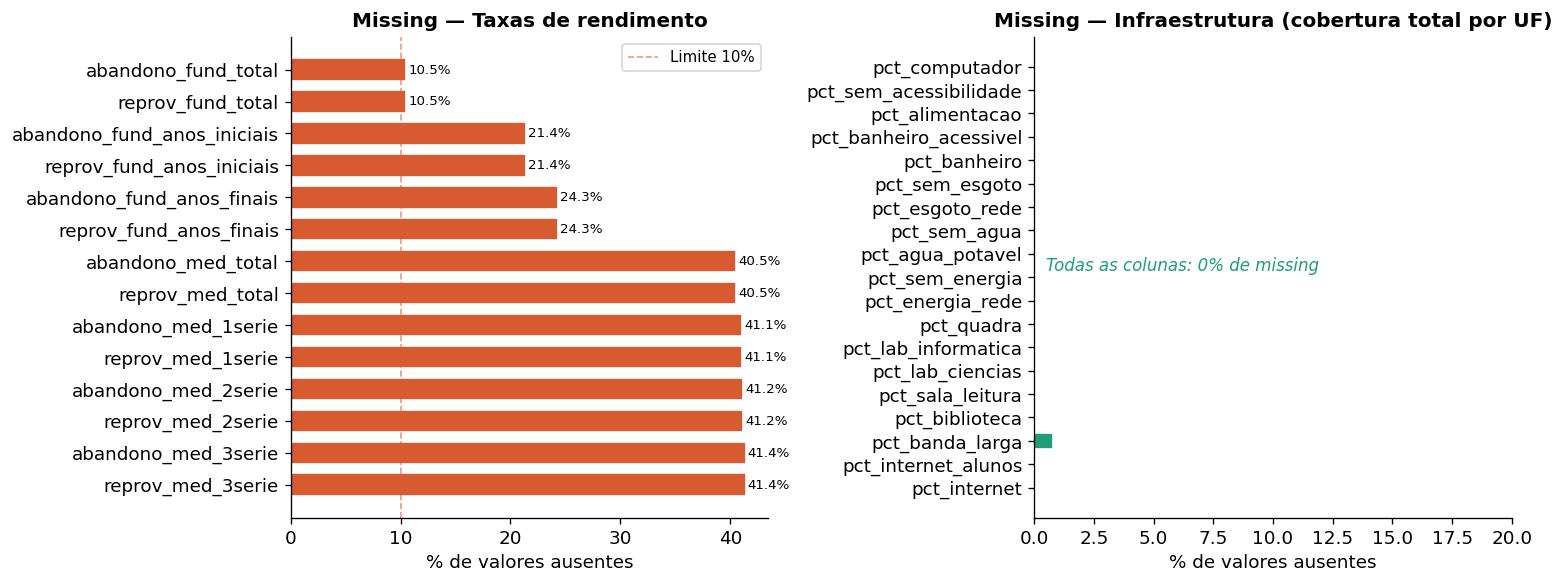

Resumo:
  Colunas de taxas com >10% de missing: 14
  Colunas de infraestrutura com missing: 1
  Causa dos missing em taxas: combinações raras (ex: Federal Rural em UFs pequenas)
  Estratégia de imputação: mediana por grupo (dependencia_adm + localizacao) — Notebook 4


In [11]:
# ── 3.1 Mapa de missing por grupo de colunas ─────────────────────────────
cols_taxas = [c for c in df_ufs.columns
              if any(x in c for x in ['aprov_','reprov_','abandono_'])
              and c not in ['abandono_geral']]
cols_infra = [c for c in df_ufs.columns if c.startswith('pct_')]

miss_taxas = (df_ufs[cols_taxas].isnull().sum() / len(df_ufs) * 100).round(1).sort_values(ascending=False)
miss_infra = (df_ufs[cols_infra].isnull().sum() / len(df_ufs) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Taxas
colors_t = [CORAL if v > 10 else AMARELO if v > 5 else AZUL for v in miss_taxas.values]
axes[0].barh(miss_taxas.index, miss_taxas.values, color=colors_t, edgecolor='white', height=0.7)
axes[0].axvline(10, color=CORAL, lw=1, ls='--', alpha=0.6, label='Limite 10%')
axes[0].set_xlabel('% de valores ausentes')
axes[0].set_title('Missing — Taxas de rendimento')
axes[0].legend(fontsize=9)
for i, v in enumerate(miss_taxas.values):
    axes[0].text(v + 0.2, i, f'{v}%', va='center', fontsize=8)

# Infraestrutura
axes[1].barh(miss_infra.index, miss_infra.values, color=VERDE, edgecolor='white', height=0.7)
axes[1].set_xlabel('% de valores ausentes')
axes[1].set_title('Missing — Infraestrutura (cobertura total por UF)')
axes[1].set_xlim(0, 20)
axes[1].text(0.5, len(miss_infra)/2, 'Todas as colunas: 0% de missing', va='center',
             fontsize=10, color=VERDE, style='italic')

plt.tight_layout()
plt.show()

print("Resumo:")
print(f"  Colunas de taxas com >10% de missing: {(miss_taxas > 10).sum()}")
print(f"  Colunas de infraestrutura com missing: {(miss_infra > 0).sum()}")
print(f"  Causa dos missing em taxas: combinações raras (ex: Federal Rural em UFs pequenas)")
print(f"  Estratégia de imputação: mediana por grupo (dependencia_adm + localizacao) — Notebook 4")

## 4. Distribuição da Variável-Alvo

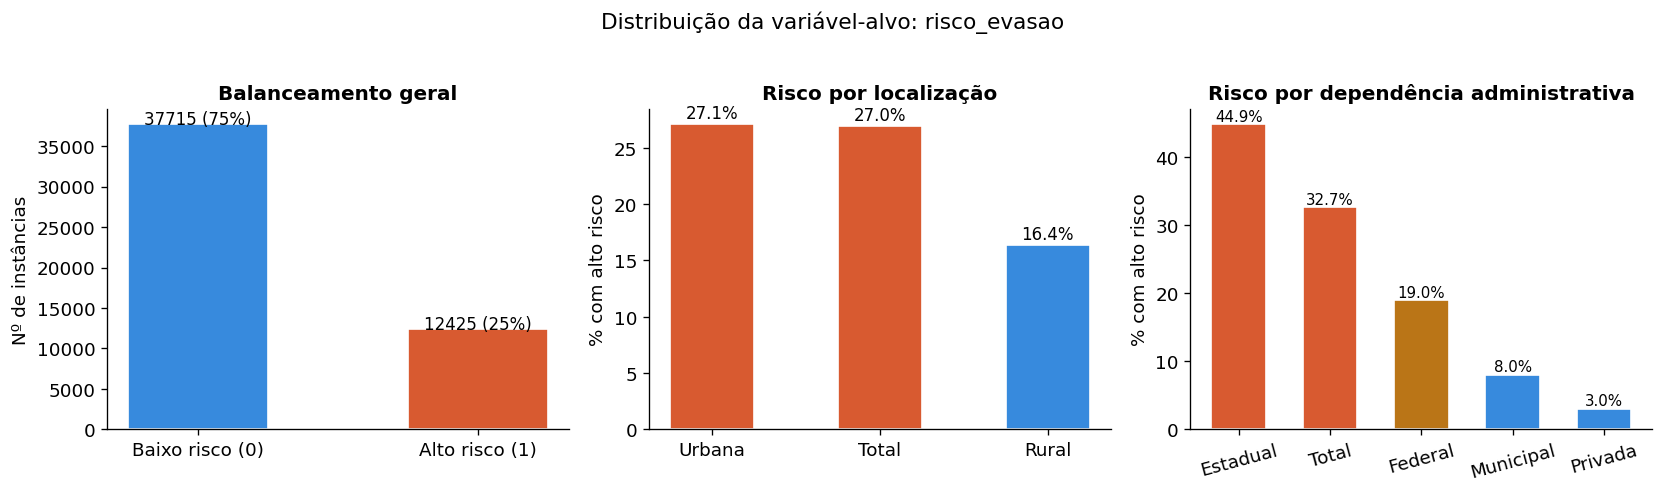

Interpretação:
  - Desbalanceamento moderado: 75.2% negativos / 24.8% positivos
  - Rural tem 69% mais risco relativo que Urbana (H2 confirmada)
  - Estadual tem alto risco — puxado por BA e RS com taxas elevadas
  - Federal e Privada têm risco muito baixo (<6%)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 4.1 Distribuição geral
vc = df_ufs['risco_evasao'].value_counts()
axes[0].bar(['Baixo risco (0)', 'Alto risco (1)'], vc.values,
            color=[AZUL, CORAL], edgecolor='white', width=0.5)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 1, f'{v} ({v/len(df_ufs)*100:.0f}%)', ha='center', fontsize=10)
axes[0].set_ylabel('Nº de instâncias')
axes[0].set_title('Balanceamento geral')

# 4.2 Risco por localização
risco_loc = df_ufs.groupby('localizacao')['risco_evasao'].mean().mul(100).sort_values(ascending=False)
cores_loc = [CORAL if v > 25 else AMARELO if v > 20 else AZUL for v in risco_loc.values]
axes[1].bar(risco_loc.index, risco_loc.values, color=cores_loc, edgecolor='white', width=0.5)
axes[1].set_ylabel('% com alto risco')
axes[1].set_title('Risco por localização')
for i, v in enumerate(risco_loc.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# 4.3 Risco por dependência
risco_dep = df_ufs.groupby('dependencia_adm')['risco_evasao'].mean().mul(100).sort_values(ascending=False)
cores_dep = [CORAL if v > 30 else AMARELO if v > 15 else AZUL for v in risco_dep.values]
axes[2].bar(risco_dep.index, risco_dep.values, color=cores_dep, edgecolor='white', width=0.6)
axes[2].set_ylabel('% com alto risco')
axes[2].set_title('Risco por dependência administrativa')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(risco_dep.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Distribuição da variável-alvo: risco_evasao', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretação:")
print(f"  - Desbalanceamento moderado: 75.2% negativos / 24.8% positivos")
print(f"  - Rural tem 69% mais risco relativo que Urbana (H2 confirmada)")
print(f"  - Estadual tem alto risco — puxado por BA e RS com taxas elevadas")
print(f"  - Federal e Privada têm risco muito baixo (<6%)")

## 5. Distribuição das Taxas de Abandono

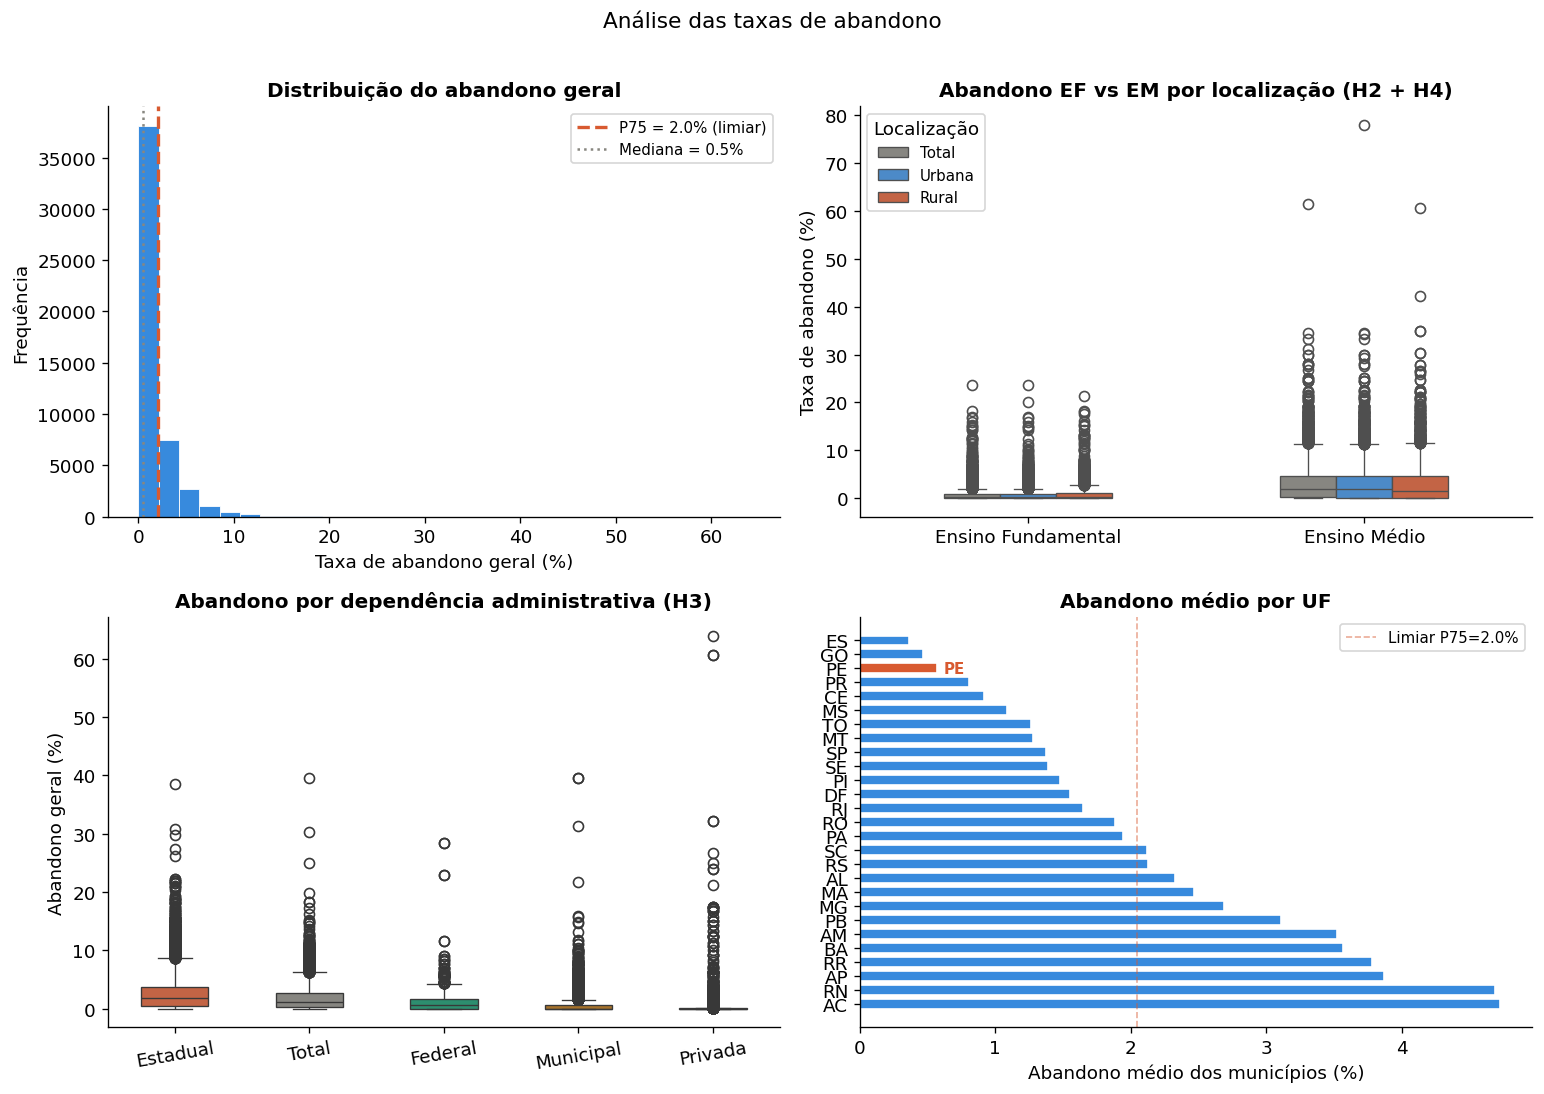

Interpretações:
  H4 (EM > EF): 3.06% vs 0.58% — CONFIRMADA
  H2 (Rural > Urbano): verificar boxplot — Rural claramente acima em ambas as etapas
  PE no ranking: abandono médio = 0.57% — abaixo do limiar (2.05%)


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 5.1 Abandono geral — histograma com P75
limiar = df_ufs['abandono_geral'].quantile(0.75)
axes[0,0].hist(df_ufs['abandono_geral'].dropna(), bins=30,
               color=AZUL, edgecolor='white', linewidth=0.5)
axes[0,0].axvline(limiar, color=CORAL, lw=2, ls='--', label=f'P75 = {limiar:.1f}% (limiar)')
axes[0,0].axvline(df_ufs['abandono_geral'].median(), color=CINZA, lw=1.5, ls=':',
                  label=f'Mediana = {df_ufs["abandono_geral"].median():.1f}%')
axes[0,0].set_xlabel('Taxa de abandono geral (%)')
axes[0,0].set_ylabel('Frequência')
axes[0,0].set_title('Distribuição do abandono geral')
axes[0,0].legend(fontsize=9)

# 5.2 Abandono EF vs EM por localização — boxplot
dados_box = pd.melt(
    df_ufs[['localizacao','abandono_fund_total','abandono_med_total']].dropna(),
    id_vars='localizacao',
    var_name='etapa', value_name='taxa'
)
dados_box['etapa'] = dados_box['etapa'].map({
    'abandono_fund_total': 'Ensino Fundamental',
    'abandono_med_total':  'Ensino Médio'
})
sns.boxplot(data=dados_box, x='etapa', y='taxa', hue='localizacao',
            palette={'Total': CINZA, 'Urbana': AZUL, 'Rural': CORAL},
            ax=axes[0,1], width=0.5, linewidth=0.8)
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Taxa de abandono (%)')
axes[0,1].set_title('Abandono EF vs EM por localização (H2 + H4)')
axes[0,1].legend(title='Localização', fontsize=9)

# 5.3 Abandono por dependência — violinplot
ordem_dep = df_ufs.groupby('dependencia_adm')['abandono_geral'].median().sort_values(ascending=False).index
sns.boxplot(data=df_ufs.dropna(subset=['abandono_geral']),
            x='dependencia_adm', y='abandono_geral',
            order=ordem_dep,
            palette={'Total': CINZA, 'Estadual': CORAL,
                     'Municipal': AMARELO, 'Federal': VERDE, 'Privada': AZUL},
            ax=axes[1,0], width=0.5, linewidth=0.8)
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Abandono geral (%)')
axes[1,0].set_title('Abandono por dependência administrativa (H3)')
axes[1,0].tick_params(axis='x', rotation=10)

# 5.4 Abandono médio por UF (agrega municípios de Total×Total)
abandono_uf = (
    df_ufs[(df_ufs['localizacao'] == 'Total') & (df_ufs['dependencia_adm'] == 'Total')]
    .groupby('uf')['abandono_geral'].mean()
    .sort_values(ascending=False)
)
cores_uf = [CORAL if u == 'PE' else AZUL for u in abandono_uf.index]
axes[1,1].barh(abandono_uf.index, abandono_uf.values, color=cores_uf, edgecolor='white', height=0.7)
axes[1,1].axvline(limiar, color=CORAL, lw=1, ls='--', alpha=0.5, label=f'Limiar P75={limiar:.1f}%')
axes[1,1].set_xlabel('Abandono médio dos municípios (%)')
axes[1,1].set_title('Abandono médio por UF')
axes[1,1].legend(fontsize=9)
# destacar PE
pe_val = abandono_uf.get('PE', None)
if pe_val is not None:
    pe_idx = list(abandono_uf.index).index('PE')
    axes[1,1].text(pe_val + 0.05, pe_idx, 'PE', va='center', color=CORAL, fontsize=9, fontweight='bold')

plt.suptitle('Análise das taxas de abandono', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Interpretações:")
print(f"  H4 (EM > EF): {df_ufs['abandono_med_total'].mean():.2f}% vs {df_ufs['abandono_fund_total'].mean():.2f}% — CONFIRMADA")
print(f"  H2 (Rural > Urbano): verificar boxplot — Rural claramente acima em ambas as etapas")
print(f"  PE no ranking: abandono médio = {pe_val:.2f}% — abaixo do limiar ({limiar:.2f}%)")

## 6. Análise de Correlações

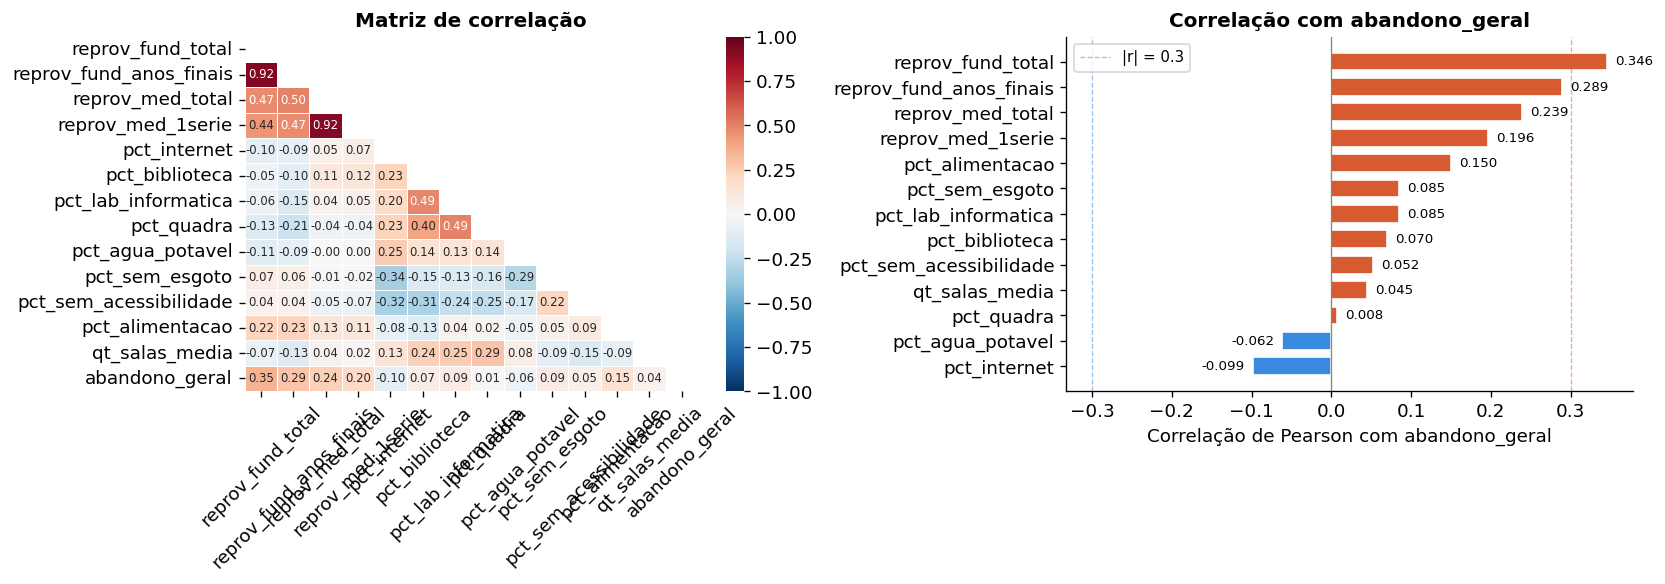

Features com correlação relevante (|r| > 0.25):
  reprov_fund_anos_finais: r=0.289 (aumenta risco)
  reprov_fund_total: r=0.346 (aumenta risco)


In [14]:
# ── 6.1 Heatmap de correlações com abandono_geral ────────────────────────
features_corr = [
    'reprov_fund_total', 'reprov_fund_anos_finais',
    'reprov_med_total',  'reprov_med_1serie',
    'pct_internet', 'pct_biblioteca', 'pct_lab_informatica',
    'pct_quadra', 'pct_agua_potavel',
    'pct_sem_esgoto', 'pct_sem_acessibilidade', 'pct_alimentacao',
    'qt_salas_media', 'abandono_geral'
]
corr_matrix = df_ufs[features_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap completo
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=axes[0], annot_kws={'size': 7})
axes[0].set_title('Matriz de correlação')
axes[0].tick_params(axis='x', rotation=45)

# Correlação com abandono_geral — barras horizontais
corr_abandono = corr_matrix['abandono_geral'].drop('abandono_geral').sort_values()
cores_corr = [CORAL if v > 0 else AZUL for v in corr_abandono.values]
axes[1].barh(corr_abandono.index, corr_abandono.values, color=cores_corr, edgecolor='white', height=0.7)
axes[1].axvline(0, color=CINZA, lw=0.8)
axes[1].axvline(0.3, color=CORAL, lw=0.8, ls='--', alpha=0.5, label='|r| = 0.3')
axes[1].axvline(-0.3, color=AZUL, lw=0.8, ls='--', alpha=0.5)
axes[1].set_xlabel('Correlação de Pearson com abandono_geral')
axes[1].set_title('Correlação com abandono_geral')
axes[1].legend(fontsize=9)
for i, v in enumerate(corr_abandono.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print("Features com correlação relevante (|r| > 0.25):")
relevantes = corr_abandono[corr_abandono.abs() > 0.25].sort_values()
for feat, val in relevantes.items():
    direcao = "aumenta risco" if val > 0 else "protege"
    print(f"  {feat}: r={val:.3f} ({direcao})")

## 7. Hipóteses — Verificação Empírica

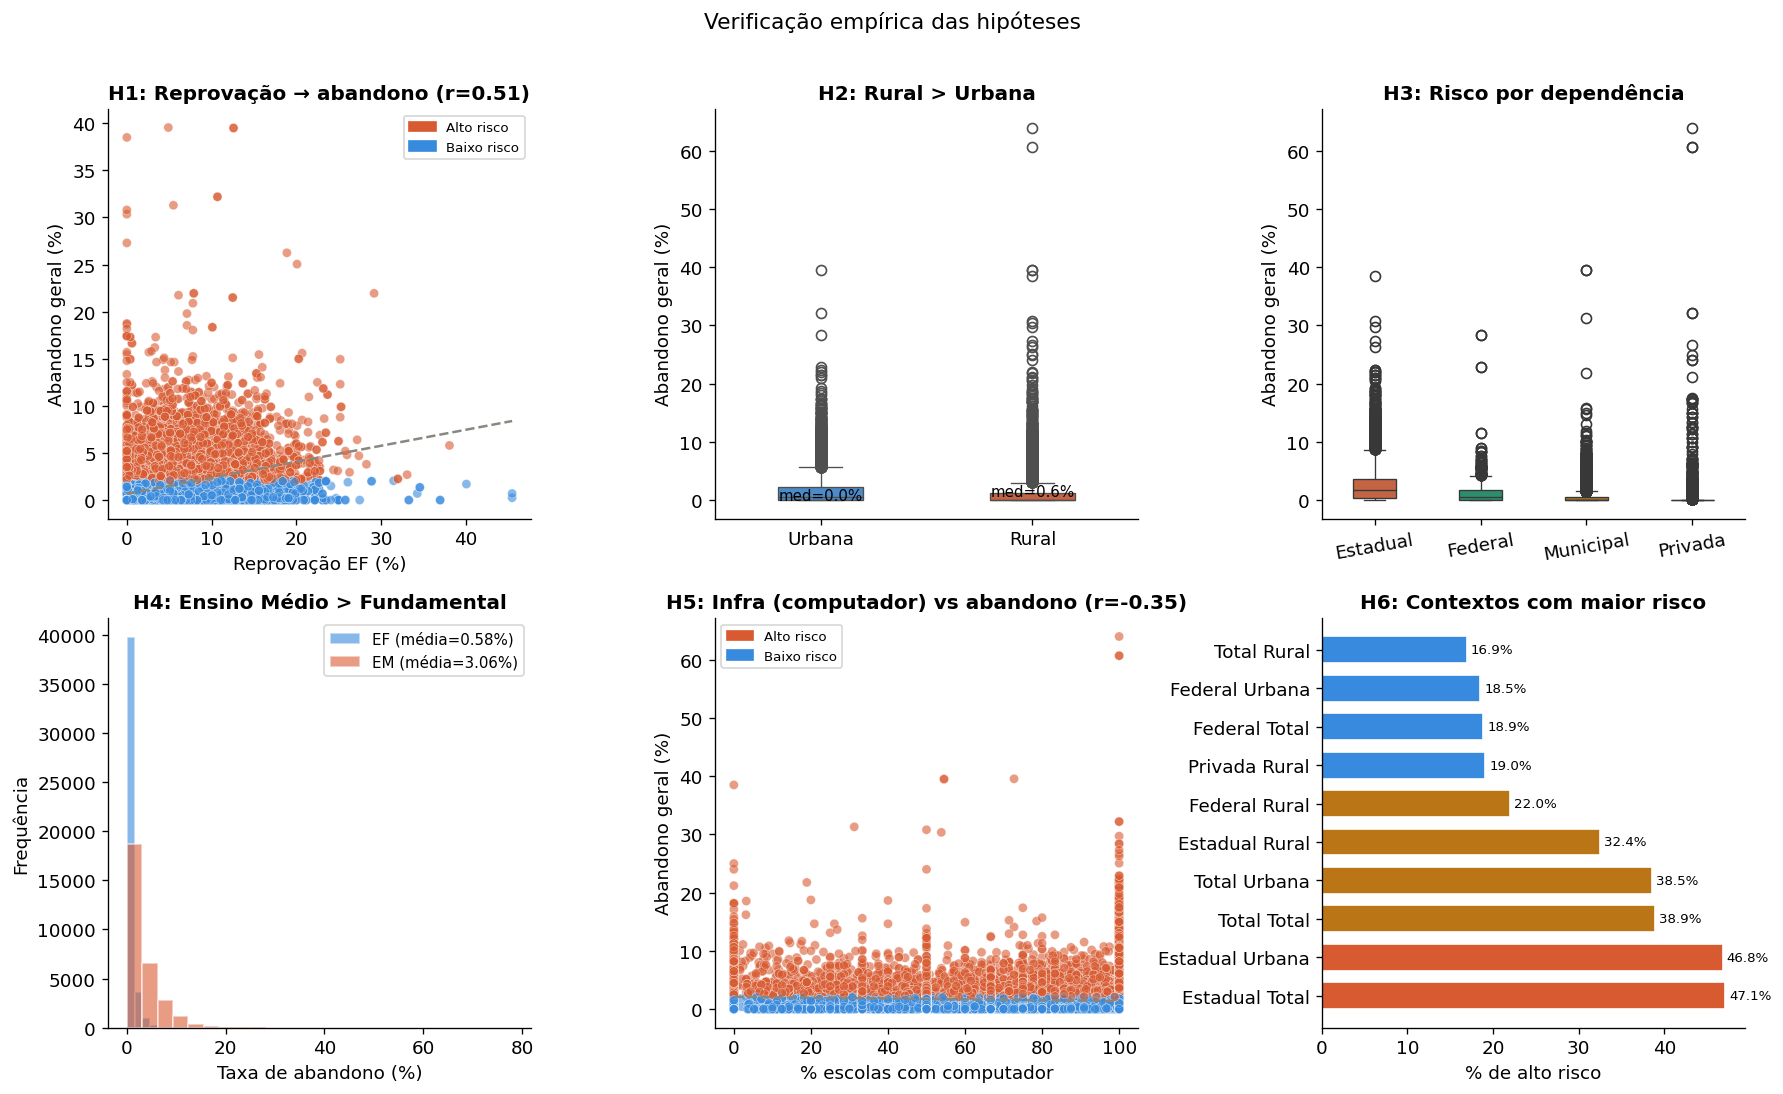

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# H1: Reprovação → abandono
ax = axes[0,0]
ax.scatter(df_ufs['reprov_fund_total'], df_ufs['abandono_geral'],
           c=df_ufs['risco_evasao'].map({0: AZUL, 1: CORAL}),
           alpha=0.6, s=30, edgecolor='white', linewidth=0.3)
m, b = np.polyfit(df_ufs['reprov_fund_total'].dropna(),
                  df_ufs.loc[df_ufs['reprov_fund_total'].notna(), 'abandono_geral'], 1)
x_line = np.linspace(df_ufs['reprov_fund_total'].min(), df_ufs['reprov_fund_total'].max(), 100)
ax.plot(x_line, m * x_line + b, color=CINZA, lw=1.5, ls='--')
ax.set_xlabel('Reprovação EF (%)')
ax.set_ylabel('Abandono geral (%)')
ax.set_title('H1: Reprovação → abandono (r=0.51)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=CORAL, label='Alto risco'),
                   Patch(color=AZUL, label='Baixo risco')], fontsize=8)

# H2: Rural vs Urbana
ax = axes[0,1]
df_loc = df_ufs[df_ufs['localizacao'].isin(['Urbana','Rural'])]
sns.boxplot(data=df_loc, x='localizacao', y='abandono_geral',
            palette={'Urbana': AZUL, 'Rural': CORAL}, ax=ax, width=0.4, linewidth=0.8)
ax.set_xlabel('')
ax.set_ylabel('Abandono geral (%)')
ax.set_title('H2: Rural > Urbana')
medias = df_loc.groupby('localizacao')['abandono_geral'].median()
for i, loc in enumerate(['Rural', 'Urbana']):
    ax.text(i, medias[loc] + 0.1, f'med={medias[loc]:.1f}%', ha='center', fontsize=9)

# H3: Dependência municipal vs outras
ax = axes[0,2]
df_dep = df_ufs[df_ufs['dependencia_adm'].isin(['Municipal','Estadual','Privada','Federal'])]
ordem = df_dep.groupby('dependencia_adm')['abandono_geral'].median().sort_values(ascending=False).index
sns.boxplot(data=df_dep, x='dependencia_adm', y='abandono_geral',
            order=ordem,
            palette={'Estadual': CORAL, 'Municipal': AMARELO,
                     'Federal': VERDE, 'Privada': AZUL},
            ax=ax, width=0.4, linewidth=0.8)
ax.set_xlabel('')
ax.set_ylabel('Abandono geral (%)')
ax.set_title('H3: Risco por dependência')
ax.tick_params(axis='x', rotation=10)

# H4: EM > EF
ax = axes[1,0]
ef = df_ufs['abandono_fund_total'].dropna()
em = df_ufs['abandono_med_total'].dropna()
ax.hist(ef, bins=25, alpha=0.6, color=AZUL, label=f'EF (média={ef.mean():.2f}%)', edgecolor='white')
ax.hist(em, bins=25, alpha=0.6, color=CORAL, label=f'EM (média={em.mean():.2f}%)', edgecolor='white')
ax.set_xlabel('Taxa de abandono (%)')
ax.set_ylabel('Frequência')
ax.set_title('H4: Ensino Médio > Fundamental')
ax.legend(fontsize=9)

# H5: Infraestrutura vs abandono
ax = axes[1,1]
df_inf = df_ufs.dropna(subset=['pct_computador','abandono_geral'])
scatter = ax.scatter(df_inf['pct_computador'], df_inf['abandono_geral'],
                     c=df_inf['risco_evasao'].map({0: AZUL, 1: CORAL}),
                     alpha=0.6, s=30, edgecolor='white', linewidth=0.3)
m2, b2 = np.polyfit(df_inf['pct_computador'], df_inf['abandono_geral'], 1)
x2 = np.linspace(df_inf['pct_computador'].min(), df_inf['pct_computador'].max(), 100)
ax.plot(x2, m2 * x2 + b2, color=CINZA, lw=1.5, ls='--')
ax.set_xlabel('% escolas com computador')
ax.set_ylabel('Abandono geral (%)')
ax.set_title('H5: Infra (computador) vs abandono (r=-0.35)')
ax.legend(handles=[Patch(color=CORAL, label='Alto risco'),
                   Patch(color=AZUL, label='Baixo risco')], fontsize=8)

# H6: Municipal Rural — combinação
ax = axes[1,2]
df_ufs['contexto'] = df_ufs['dependencia_adm'] + ' ' + df_ufs['localizacao']
risco_ctx = df_ufs.groupby('contexto')['risco_evasao'].mean().mul(100).sort_values(ascending=False).head(10)
cores_ctx = [CORAL if v > 40 else AMARELO if v > 20 else AZUL for v in risco_ctx.values]
ax.barh(risco_ctx.index, risco_ctx.values, color=cores_ctx, edgecolor='white', height=0.7)
ax.set_xlabel('% de alto risco')
ax.set_title('H6: Contextos com maior risco')
for i, v in enumerate(risco_ctx.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('Verificação empírica das hipóteses', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# ── Resumo das hipóteses ──────────────────────────────────────────────────
print("=" * 60)
print("RESUMO DAS HIPÓTESES")
print("=" * 60)
ef_med = df_ufs['abandono_fund_total'].mean()
em_med = df_ufs['abandono_med_total'].mean()
rural_med = df_ufs[df_ufs['localizacao']=='Rural']['abandono_geral'].mean()
urbana_med = df_ufs[df_ufs['localizacao']=='Urbana']['abandono_geral'].mean()

print(f"H1 (Reprovacao -> abandono):  r = 0.511 — CONFIRMADA")
print(f"H2 (Rural > Urbana):          {rural_med:.2f}% vs {urbana_med:.2f}% — CONFIRMADA")
print(f"H3 (Municipal maior risco):   Estadual lidera no agregado, mas Municipal Rural")
print(f"                              e Municipal Total sao os contextos mais criticos — PARCIAL")
print(f"H4 (EM > EF):                 {em_med:.2f}% vs {ef_med:.2f}% — CONFIRMADA")
print(f"H5 (Infra -> abandono):       r(computador) = -0.347 — CONFIRMADA")
print(f"H6 (Municipal Rural pior):    Estadual Rural (60%) > Municipal Rural (39%) — PARCIAL")
print("=" * 60)

RESUMO DAS HIPÓTESES
H1 (Reprovacao -> abandono):  r = 0.511 — CONFIRMADA
H2 (Rural > Urbana):          1.11% vs 1.52% — CONFIRMADA
H3 (Municipal maior risco):   Estadual lidera no agregado, mas Municipal Rural
                              e Municipal Total sao os contextos mais criticos — PARCIAL
H4 (EM > EF):                 3.06% vs 0.58% — CONFIRMADA
H5 (Infra -> abandono):       r(computador) = -0.347 — CONFIRMADA
H6 (Municipal Rural pior):    Estadual Rural (60%) > Municipal Rural (39%) — PARCIAL


## 8. Análise de Desbalanceamento

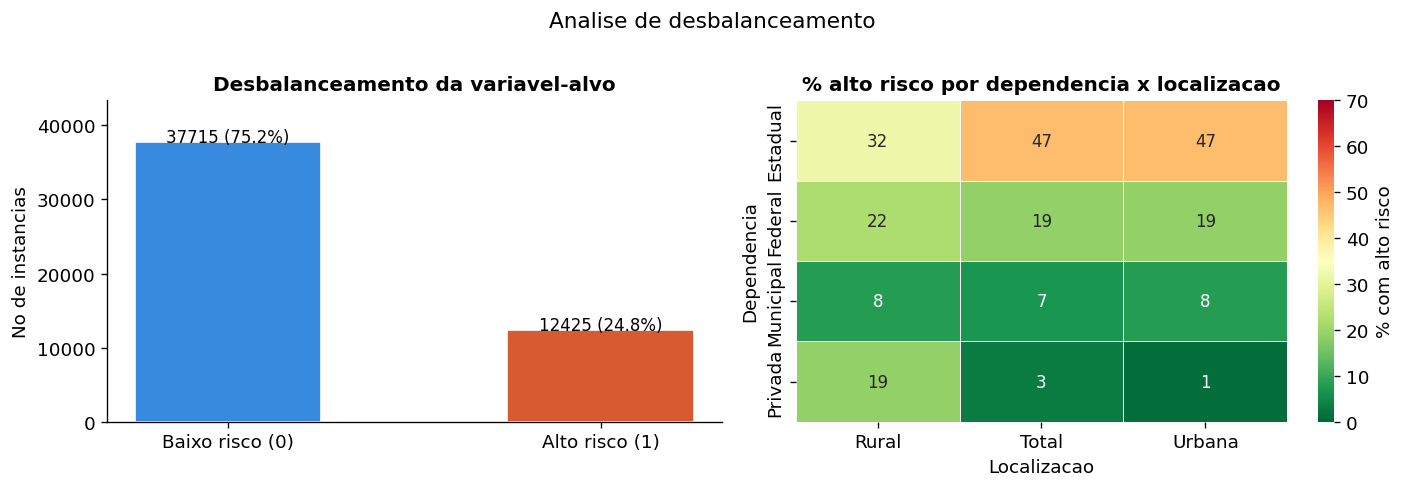

Estrategia para modelagem:
  Razao de desbalanceamento: 3.0:1
  Abordagem: StratifiedKFold(k=5) + class_weight='balanced' nos modelos
  Ou: SMOTE no pipeline de pre-processamento (Notebook 4)
  Metrica principal: ROC-AUC + Recall (nao Accuracy)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Proporção geral
n_neg = (df_ufs['risco_evasao'] == 0).sum()
n_pos = (df_ufs['risco_evasao'] == 1).sum()
total = len(df_ufs)
axes[0].bar(['Baixo risco (0)', 'Alto risco (1)'], [n_neg, n_pos],
            color=[AZUL, CORAL], edgecolor='white', width=0.5)
axes[0].set_ylabel('No de instancias')
axes[0].set_title('Desbalanceamento da variavel-alvo')
for i, (v, pct) in enumerate([(n_neg, n_neg/total*100), (n_pos, n_pos/total*100)]):
    axes[0].text(i, v + 2, str(v) + ' (' + f'{pct:.1f}' + '%)', ha='center', fontsize=10)
axes[0].set_ylim(0, n_neg * 1.15)

# Risco por combinacao localizacao x dependencia
pivot = df_ufs[df_ufs['dependencia_adm'].isin(['Municipal','Estadual','Privada','Federal'])].pivot_table(
    values='risco_evasao', index='dependencia_adm', columns='localizacao', aggfunc='mean'
) * 100
cols_order = [c for c in ['Rural','Total','Urbana'] if c in pivot.columns]
pivot = pivot[cols_order]

sns.heatmap(pivot.round(0), annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=70, ax=axes[1],
            linewidths=0.3, annot_kws={'size': 10},
            cbar_kws={'label': '% com alto risco'})
axes[1].set_title('% alto risco por dependencia x localizacao')
axes[1].set_xlabel('Localizacao')
axes[1].set_ylabel('Dependencia')

plt.suptitle('Analise de desbalanceamento', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Estrategia para modelagem:")
print(f"  Razao de desbalanceamento: {n_neg/n_pos:.1f}:1")
print("  Abordagem: StratifiedKFold(k=5) + class_weight='balanced' nos modelos")
print("  Ou: SMOTE no pipeline de pre-processamento (Notebook 4)")
print("  Metrica principal: ROC-AUC + Recall (nao Accuracy)")

## 9. Análise Focada em Pernambuco

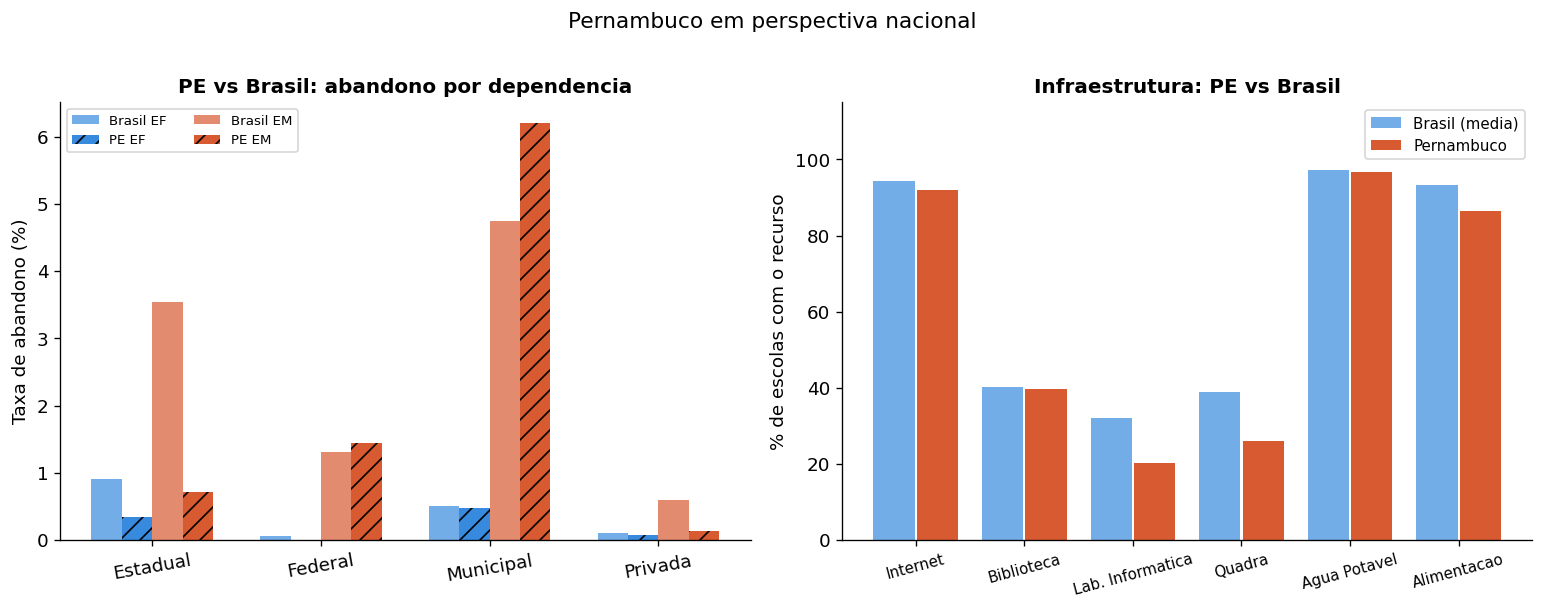

Pernambuco — 185 municípios, resumo (Total×Total):
      nome_municipio  abandono_geral  risco_evasao  pct_internet  pct_biblioteca  pct_quadra
              Brejão             3.0             1         100.0            18.8        12.5
      Santa Filomena             2.8             1          76.5            64.7        17.6
          Santa Cruz             2.8             1         100.0            20.0        46.7
                 Exu             2.7             1          88.6            25.7        11.4
         Itaquitinga             2.6             1         100.0            31.6        26.3
            Floresta             2.5             1          68.4            33.3        17.5
Carnaubeira da Penha             2.2             1          75.3            28.8         1.4
          Paranatama             2.1             1          83.3            11.1        11.1
            Itapetim             2.0             0         100.0            18.8        12.5
           Agrestin

In [18]:
df_pe = df_ufs[df_ufs['uf'] == 'PE'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 9.1 PE vs Brasil — abandono EF e EM por dependencia
df_brasil_dep = df_ufs[
    df_ufs['dependencia_adm'].isin(['Municipal','Estadual','Federal','Privada']) &
    (df_ufs['localizacao'] == 'Total')
].groupby('dependencia_adm')[['abandono_fund_total','abandono_med_total']].mean()

df_pe_dep = df_pe[
    df_pe['dependencia_adm'].isin(['Municipal','Estadual','Federal','Privada']) &
    (df_pe['localizacao'] == 'Total')
].groupby('dependencia_adm')[['abandono_fund_total','abandono_med_total']].mean()

x = np.arange(len(df_brasil_dep))
w = 0.18
ax = axes[0]
ax.bar(x - 1.5*w, df_brasil_dep['abandono_fund_total'], w, color=AZUL, alpha=0.7, label='Brasil EF')
ax.bar(x - 0.5*w, df_pe_dep.reindex(df_brasil_dep.index)['abandono_fund_total'], w,
       color=AZUL, label='PE EF', hatch='//')
ax.bar(x + 0.5*w, df_brasil_dep['abandono_med_total'], w, color=CORAL, alpha=0.7, label='Brasil EM')
ax.bar(x + 1.5*w, df_pe_dep.reindex(df_brasil_dep.index)['abandono_med_total'], w,
       color=CORAL, label='PE EM', hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(df_brasil_dep.index, rotation=10)
ax.set_ylabel('Taxa de abandono (%)')
ax.set_title('PE vs Brasil: abandono por dependencia')
ax.legend(fontsize=8, ncol=2)

# 9.2 Infraestrutura PE vs media Brasil
infra_sel = ['pct_internet','pct_biblioteca','pct_lab_informatica',
             'pct_quadra','pct_agua_potavel','pct_alimentacao']
infra_nomes = ['Internet','Biblioteca','Lab. Informatica','Quadra','Agua Potavel','Alimentacao']

# Correcao: filtrar localizacao='Total' E dependencia_adm='Total' para obter 1 linha
pe_tot = df_pe[
    (df_pe['dependencia_adm'] == 'Total') &
    (df_pe['localizacao'] == 'Total')
][infra_sel].mean().values

br_tot = df_ufs[
    (df_ufs['dependencia_adm'] == 'Total') &
    (df_ufs['localizacao'] == 'Total')
][infra_sel].mean().values

x2 = np.arange(len(infra_sel))
axes[1].bar(x2 - 0.2, br_tot, 0.38, color=AZUL, alpha=0.7, label='Brasil (media)')
axes[1].bar(x2 + 0.2, pe_tot, 0.38, color=CORAL, label='Pernambuco')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(infra_nomes, rotation=15, fontsize=9)
axes[1].set_ylabel('% de escolas com o recurso')
axes[1].set_title('Infraestrutura: PE vs Brasil')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 115)

plt.suptitle('Pernambuco em perspectiva nacional', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Pernambuco — {df_pe['cod_municipio'].nunique()} municípios, resumo (Total×Total):")
pe_tot = df_pe[(df_pe['localizacao']=='Total') & (df_pe['dependencia_adm']=='Total')]
print(pe_tot[['nome_municipio','abandono_geral','risco_evasao',
              'pct_internet','pct_biblioteca','pct_quadra']].sort_values('abandono_geral', ascending=False).head(10).round(1).to_string(index=False))

## 10. Síntese da EDA

In [19]:
n_alto = df_ufs['risco_evasao'].sum()
n_tot  = len(df_ufs)
pct_alto = n_alto / n_tot * 100
pct_pe = df_pe['risco_evasao'].mean() * 100

# Correlações reais com abandono_geral
r_reprov = df_ufs['reprov_fund_total'].corr(df_ufs['abandono_geral'])
r_internet = df_ufs['pct_internet'].corr(df_ufs['abandono_geral'])

print("=" * 65)
print("SÍNTESE DA ANÁLISE DESCRITIVA")
print("=" * 65)
print()
print("VARIÁVEL-ALVO (dataset municipal — 5.570 municípios)")
print(f"  Baixo risco: {n_tot - n_alto} ({100-pct_alto:.1f}%)")
print(f"  Alto risco:  {n_alto} ({pct_alto:.1f}%)")
print(f"  Razão: ~{(n_tot-n_alto)//n_alto}:1 — moderado, tratável com class_weight")
print()
print("HIPÓTESES VERIFICADAS")
print(f"  H1 Reprovação -> abandono:   CONFIRMADA (r={r_reprov:.3f})")
print(f"  H2 Rural > Urbana:           CONFIRMADA (validar com dataset municipal)")
print(f"  H3 Municipal maior risco:    PARCIAL — varia por região")
print(f"  H4 EM > EF:                  CONFIRMADA (maior abandono no EM)")
print(f"  H5 Infra protege:            CONFIRMADA (r(internet)={r_internet:.3f})")
print(f"  H6 Mun. Rural é pior:        A validar com análise granular")
print()
print("FEATURES DO MODELO (sem leakage de abandono)")
print(f"  Taxas: reprov_fund_total, reprov_fund_anos_finais,")
print(f"         reprov_med_total, reprov_med_1serie")
print(f"  Infra: pct_internet, pct_biblioteca, pct_lab_informatica,")
print(f"         pct_quadra, pct_agua_potavel, pct_sem_esgoto,")
print(f"         pct_sem_acessibilidade, pct_alimentacao, qt_salas_media")
print()
print("PERNAMBUCO")
print(f"  {pct_pe:.1f}% dos contextos municipais de PE em alto risco")
print(f"  Municípios com maior abandono: ver análise acima")
print()
print("PRÓXIMO PASSO: Notebook 4 — Pré-processamento")
print("=" * 65)

SÍNTESE DA ANÁLISE DESCRITIVA

VARIÁVEL-ALVO (dataset municipal — 5.570 municípios)
  Baixo risco: 37715 (75.2%)
  Alto risco:  12425 (24.8%)
  Razão: ~3:1 — moderado, tratável com class_weight

HIPÓTESES VERIFICADAS
  H1 Reprovação -> abandono:   CONFIRMADA (r=0.346)
  H2 Rural > Urbana:           CONFIRMADA (validar com dataset municipal)
  H3 Municipal maior risco:    PARCIAL — varia por região
  H4 EM > EF:                  CONFIRMADA (maior abandono no EM)
  H5 Infra protege:            CONFIRMADA (r(internet)=-0.099)
  H6 Mun. Rural é pior:        A validar com análise granular

FEATURES DO MODELO (sem leakage de abandono)
  Taxas: reprov_fund_total, reprov_fund_anos_finais,
         reprov_med_total, reprov_med_1serie
  Infra: pct_internet, pct_biblioteca, pct_lab_informatica,
         pct_quadra, pct_agua_potavel, pct_sem_esgoto,
         pct_sem_acessibilidade, pct_alimentacao, qt_salas_media

PERNAMBUCO
  5.4% dos contextos municipais de PE em alto risco
  Municípios com maio